# 03（US）干支效应主分析（分组统计 + 显著性 + FDR）

目标：合并 `02` 生成的交易日干支表与美国宽基指数日线数据，输出分组统计、显著性检验与最小图表。

输入：
- `data/cache_us/index_daily/{symbol_id}.csv.gz`
- `data/clean_us/ganzhi_trade_dates.csv.gz`

输出（写入 `data/clean_us/`）：
- `market_{symbol_id}.csv.gz`
- `market_ganzhi_{symbol_id}.csv.gz`
- `ganzhi_stats_{symbol_id}.csv`
- `ganzhi_tests_{symbol_id}.csv`


Using Chinese font: Microsoft YaHei
PROJECT_ROOT = D:\Work\中国传统投资\风水五行阴阳天干地支
Loaded ganzhi rows = 4055
---
symbol_id: spx
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean_us\market_spx.csv.gz
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean_us\market_ganzhi_spx.csv.gz
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean_us\ganzhi_stats_spx.csv
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean_us\ganzhi_tests_spx.csv


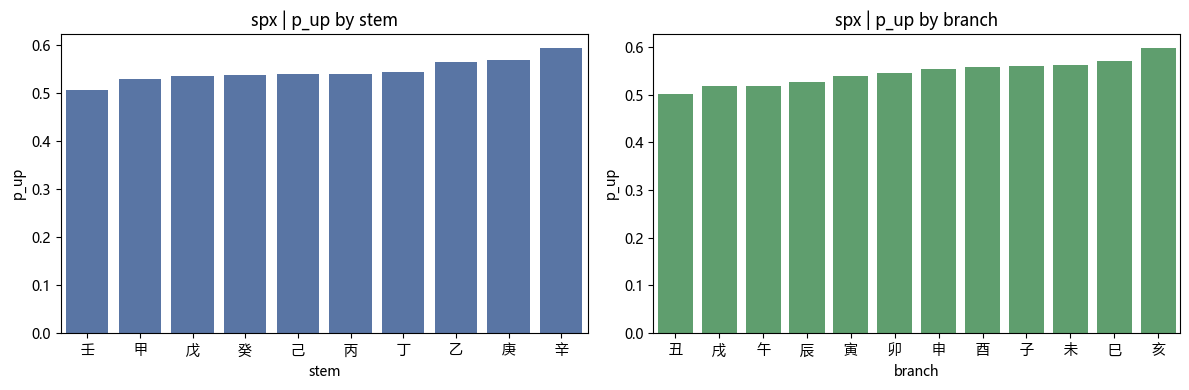

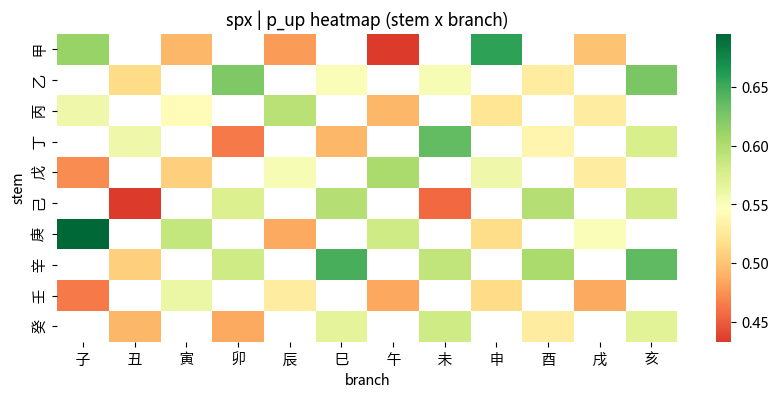

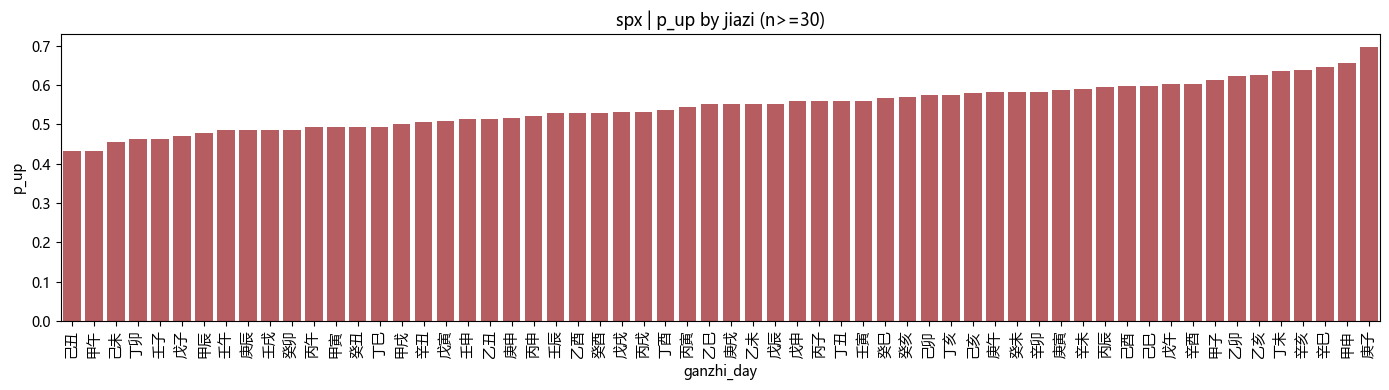

---
symbol_id: ndq
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean_us\market_ndq.csv.gz
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean_us\market_ganzhi_ndq.csv.gz
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean_us\ganzhi_stats_ndq.csv
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean_us\ganzhi_tests_ndq.csv


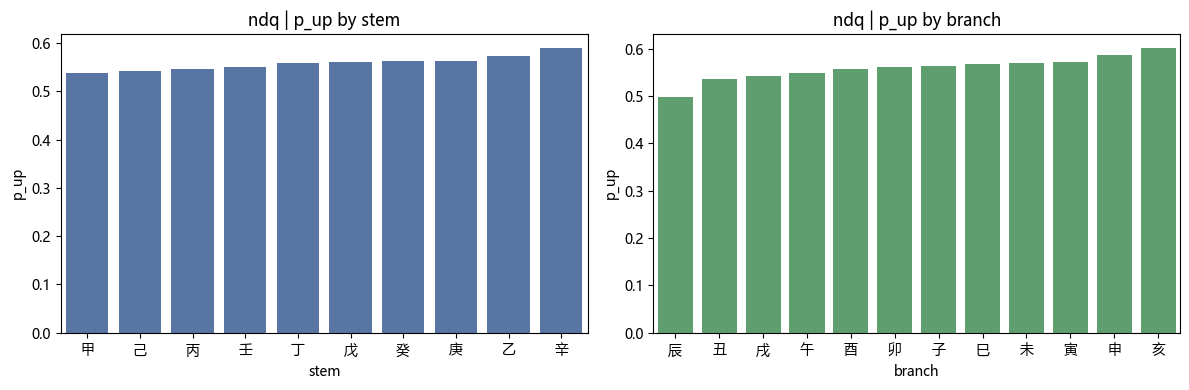

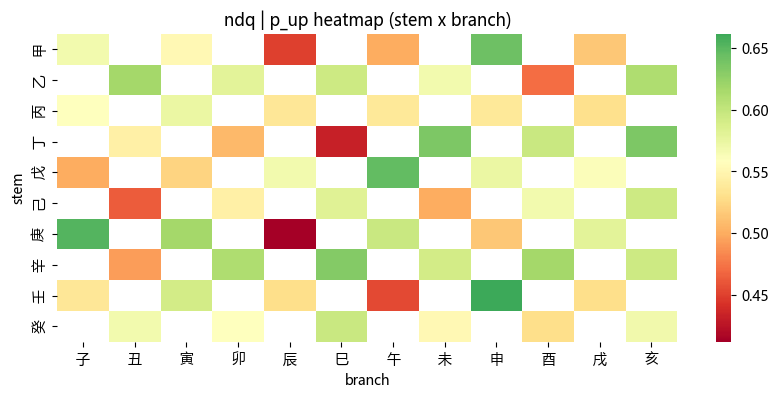

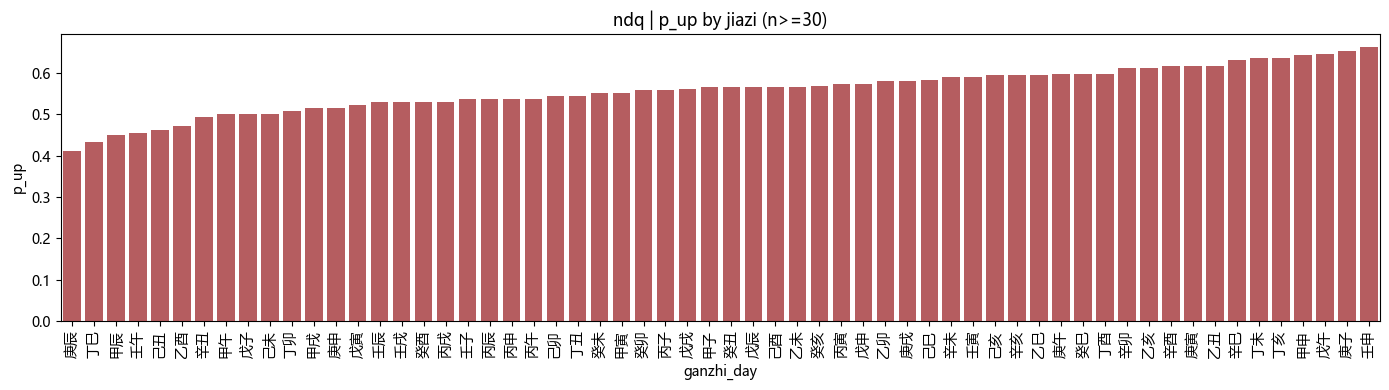

---
symbol_id: ndx
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean_us\market_ndx.csv.gz
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean_us\market_ganzhi_ndx.csv.gz
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean_us\ganzhi_stats_ndx.csv
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean_us\ganzhi_tests_ndx.csv


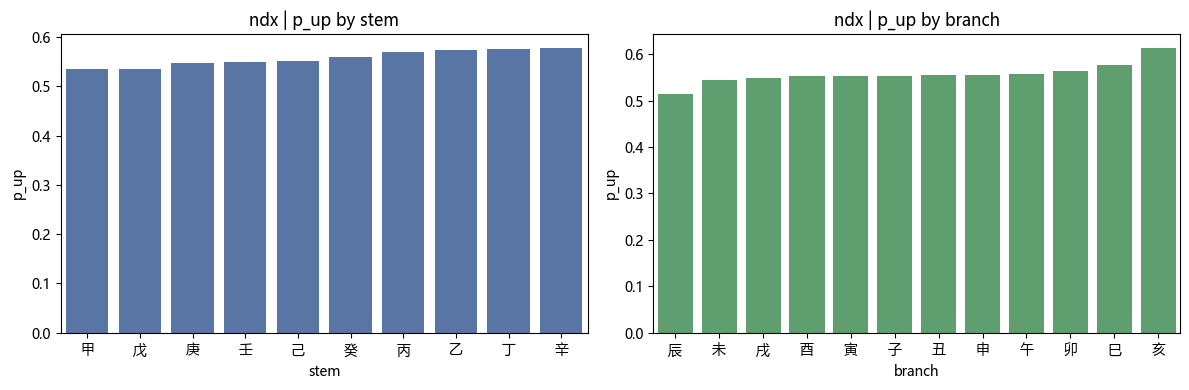

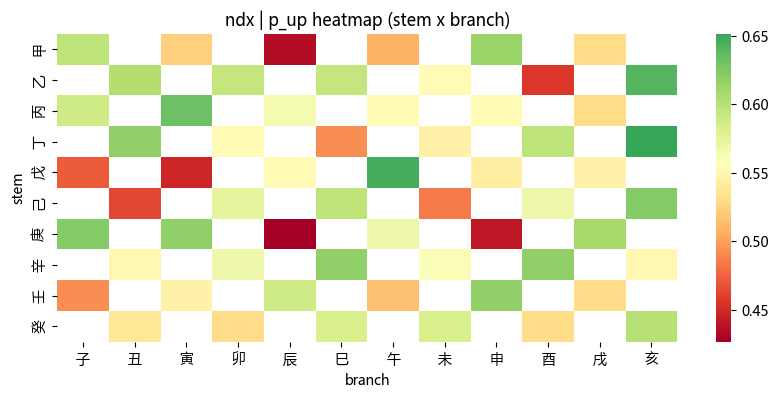

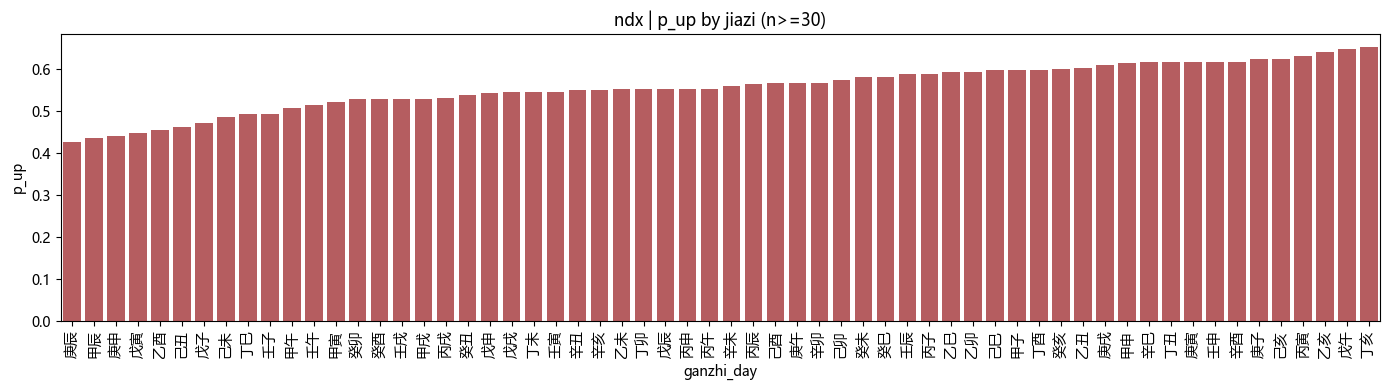

---
symbol_id: dji
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean_us\market_dji.csv.gz
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean_us\market_ganzhi_dji.csv.gz
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean_us\ganzhi_stats_dji.csv
saved: D:\Work\中国传统投资\风水五行阴阳天干地支\data\clean_us\ganzhi_tests_dji.csv


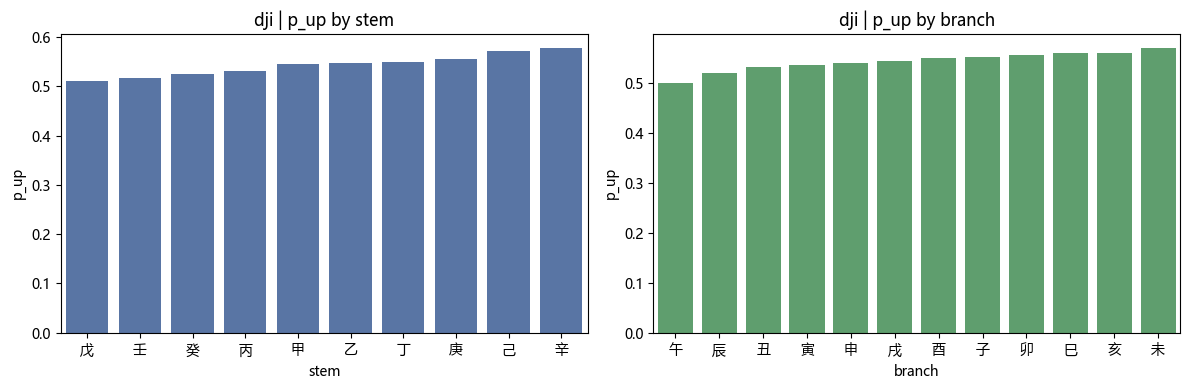

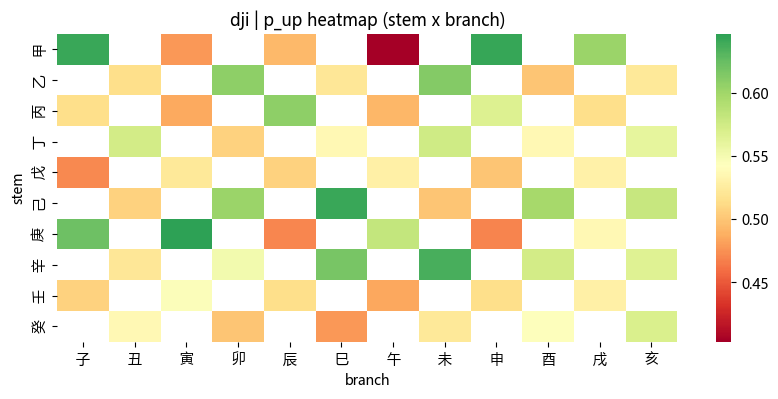

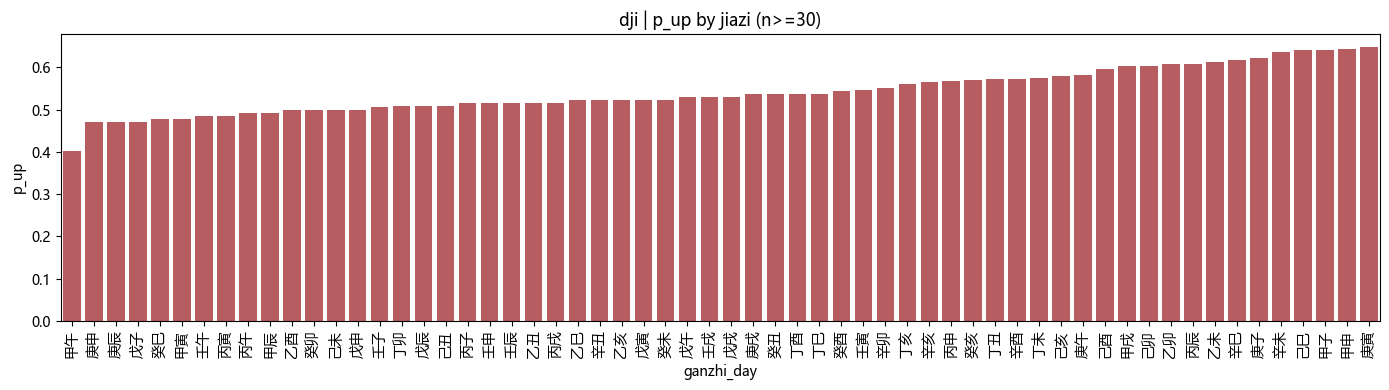

,symbol_id,n_days,p_up_all,mean_ret_all
0,spx,4053,0.546509,0.000503
1,ndq,4054,0.558461,0.000646
2,ndx,4053,0.557365,0.000721
3,dji,4053,0.542561,0.000435


In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



from matplotlib import font_manager, rcParams


def set_chinese_font() -> None:
    # Best-effort Chinese font setup for Matplotlib.
    # - Tries common Linux CJK fonts
    # - On WSL, also tries registering Windows fonts under /mnt/c/Windows/Fonts

    candidates = [
        'Noto Sans CJK SC',
        'Noto Sans CJK TC',
        'Noto Sans CJK JP',
        'Source Han Sans SC',
        'WenQuanYi Micro Hei',
        'Microsoft YaHei',
        'SimHei',
        'SimSun',
        'Arial Unicode MS',
    ]

    # WSL fallback: register Windows fonts if available
    try:
        from pathlib import Path as _Path

        win_dir = _Path('/mnt/c/Windows/Fonts')
        win_files = [
            win_dir / 'msyh.ttc',
            win_dir / 'msyhbd.ttc',
            win_dir / 'simhei.ttf',
            win_dir / 'simsun.ttc',
            win_dir / 'arialuni.ttf',
        ]

        extra_names: list[str] = []
        addfont = getattr(font_manager.fontManager, 'addfont', None)
        for fp in win_files:
            try:
                if fp.is_file():
                    if callable(addfont):
                        addfont(str(fp))
                    extra_names.append(font_manager.FontProperties(fname=str(fp)).get_name())
            except Exception:
                continue

        candidates = [n for n in extra_names if n] + candidates
    except Exception:
        pass

    for name in candidates:
        try:
            font_manager.findfont(name, fallback_to_default=False)
            rcParams['font.sans-serif'] = [name]
            rcParams['axes.unicode_minus'] = False
            print(f'Using Chinese font: {name}')
            return
        except Exception:
            continue

    rcParams['axes.unicode_minus'] = False
    print(
        'Warning: no Chinese font found; Chinese labels may not render. '
        'If you are on WSL, ensure Windows fonts are accessible under /mnt/c/Windows/Fonts; '
        'or install Noto CJK fonts in Linux (e.g., fonts-noto-cjk).'
    )


set_chinese_font()

def find_project_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()

    for candidate in [here] + list(here.parents):
        if (candidate / 'AGENTS.md').is_file() and (candidate / 'data').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate

    for candidate in here.glob('*'):
        if candidate.is_dir() and (candidate / 'AGENTS.md').is_file() and (candidate / 'data').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate

    return here


ROOT = find_project_root()
print('PROJECT_ROOT =', ROOT)

CACHE_DIR = ROOT / 'data/cache_us'
CLEAN_DIR = ROOT / 'data/clean_us'
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

# Default universe (skip if cache missing)
SYMBOL_IDS = ['spx', 'ndq', 'ndx', 'dji']

MIN_N_FOR_JIAZI_PLOT = 30


def fdr_bh(pvals: np.ndarray) -> np.ndarray:
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(p)
    q = np.empty(n, dtype=float)
    prev = 1.0
    for rank in range(n - 1, -1, -1):
        i = order[rank]
        val = p[i] * n / (rank + 1)
        prev = min(prev, val)
        q[i] = prev
    return np.clip(q, 0.0, 1.0)


def load_index_daily(symbol_id: str) -> pd.DataFrame | None:
    path = CACHE_DIR / 'index_daily' / f'{symbol_id}.csv.gz'
    if not path.exists():
        return None
    df = pd.read_csv(path, compression='gzip', dtype={'trade_date': str})
    if df.empty:
        return None
    return df.sort_values(['trade_date']).reset_index(drop=True)


def build_market_table(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if 'trade_date' not in out.columns or 'close' not in out.columns:
        raise ValueError(f'Unexpected columns: {out.columns.tolist()}')

    out['trade_date'] = out['trade_date'].astype(str)
    out = out.sort_values(['trade_date']).reset_index(drop=True)

    out['pre_close'] = out['close'].shift(1)
    out['ret_1d'] = out['close'] / out['pre_close'] - 1.0
    out = out.dropna(subset=['ret_1d']).copy()
    out['up'] = (out['ret_1d'] > 0).astype(int)

    keep = ['trade_date', 'close', 'pre_close', 'ret_1d', 'up']
    for col in ['symbol', 'symbol_id', 'open', 'high', 'low', 'volume']:
        if col in out.columns:
            keep.insert(0, col)

    return out[keep].copy()


def group_stats(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    g = df.groupby(group_col, dropna=False)
    return (
        g.agg(
            n=('ret_1d', 'size'),
            p_up=('up', 'mean'),
            mean_ret=('ret_1d', 'mean'),
            median_ret=('ret_1d', 'median'),
            std_ret=('ret_1d', 'std'),
            q05_ret=('ret_1d', lambda x: float(np.nanquantile(x, 0.05))),
        )
        .reset_index()
    )


def per_group_tests(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    overall_p = float(df['up'].mean())
    overall_mean = float(df['ret_1d'].mean())

    records: list[dict] = []
    for val, sub in df.groupby(group_col, dropna=False):
        n = int(len(sub))
        if n <= 5:
            continue

        k = int(sub['up'].sum())
        p_up = float(sub['up'].mean())
        pval_up = stats.binomtest(k, n, overall_p, alternative='two-sided').pvalue
        records.append(
            {
                'group_type': group_col,
                'group_value': str(val),
                'metric': 'p_up',
                'n': n,
                'effect': p_up - overall_p,
                'p_value': float(pval_up),
            }
        )

        other = df.loc[df[group_col] != val, 'ret_1d']
        if other.notna().sum() > 5 and sub['ret_1d'].notna().sum() > 5:
            t = stats.ttest_ind(sub['ret_1d'], other, equal_var=False, nan_policy='omit')
            pval_ret = float(t.pvalue)
        else:
            pval_ret = np.nan

        records.append(
            {
                'group_type': group_col,
                'group_value': str(val),
                'metric': 'mean_ret',
                'n': n,
                'effect': float(sub['ret_1d'].mean()) - overall_mean,
                'p_value': pval_ret,
            }
        )

    out = pd.DataFrame.from_records(records)
    if out.empty:
        return out

    out['q_value'] = np.nan
    for (gt, metric), idx in out.groupby(['group_type', 'metric']).groups.items():
        pvals = out.loc[idx, 'p_value'].to_numpy(dtype=float)
        ok = np.isfinite(pvals)
        q = np.full_like(pvals, np.nan, dtype=float)
        if ok.sum() > 0:
            q[ok] = fdr_bh(pvals[ok])
        out.loc[idx, 'q_value'] = q

    return out


# load ganzhi calendar

ganzhi_path = CLEAN_DIR / 'ganzhi_trade_dates.csv.gz'
if not ganzhi_path.exists():
    raise FileNotFoundError('Missing data/clean_us/ganzhi_trade_dates.csv.gz. Run notebooks_US/02 first.')

ganzhi = pd.read_csv(ganzhi_path, compression='gzip', dtype={'trade_date': str})
print('Loaded ganzhi rows =', len(ganzhi))

results = []

for symbol_id in SYMBOL_IDS:
    raw = load_index_daily(symbol_id)
    if raw is None:
        print('Skip missing cache:', symbol_id)
        continue

    market = build_market_table(raw)
    market_path = CLEAN_DIR / f'market_{symbol_id}.csv.gz'
    market.to_csv(market_path, index=False, compression='gzip')

    merged = market.merge(ganzhi, on='trade_date', how='left')
    merged_path = CLEAN_DIR / f'market_ganzhi_{symbol_id}.csv.gz'
    merged.to_csv(merged_path, index=False, compression='gzip')

    stats_stem = group_stats(merged, 'stem')
    stats_branch = group_stats(merged, 'branch')
    stats_jiazi = group_stats(merged, 'ganzhi_day')

    stats_all = pd.concat(
        [
            stats_stem.assign(group_type='stem').rename(columns={'stem': 'group_value'}),
            stats_branch.assign(group_type='branch').rename(columns={'branch': 'group_value'}),
            stats_jiazi.assign(group_type='ganzhi_day').rename(columns={'ganzhi_day': 'group_value'}),
        ],
        ignore_index=True,
    )

    stats_path = CLEAN_DIR / f'ganzhi_stats_{symbol_id}.csv'
    stats_all.to_csv(stats_path, index=False)

    tests = pd.concat(
        [
            per_group_tests(merged, 'stem'),
            per_group_tests(merged, 'branch'),
            per_group_tests(merged, 'ganzhi_day'),
        ],
        ignore_index=True,
    )

    tests_path = CLEAN_DIR / f'ganzhi_tests_{symbol_id}.csv'
    tests.to_csv(tests_path, index=False)

    print('---')
    print('symbol_id:', symbol_id)
    print('saved:', market_path)
    print('saved:', merged_path)
    print('saved:', stats_path)
    print('saved:', tests_path)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.barplot(data=stats_stem.sort_values('p_up'), x='stem', y='p_up', ax=axes[0], color='#4C72B0')
    axes[0].set_title(f'{symbol_id} | p_up by stem')
    sns.barplot(data=stats_branch.sort_values('p_up'), x='branch', y='p_up', ax=axes[1], color='#55A868')
    axes[1].set_title(f'{symbol_id} | p_up by branch')
    plt.tight_layout()
    plt.show()

    heat = (
        merged.groupby(['stem', 'branch'])['up']
        .mean()
        .reset_index()
        .pivot(index='stem', columns='branch', values='up')
        .reindex(index=list('甲乙丙丁戊己庚辛壬癸'), columns=list('子丑寅卯辰巳午未申酉戌亥'))
    )

    plt.figure(figsize=(10, 4))
    sns.heatmap(heat, annot=False, cmap='RdYlGn', center=float(merged['up'].mean()))
    plt.title(f'{symbol_id} | p_up heatmap (stem x branch)')
    plt.show()

    jiazi_plot = stats_jiazi.loc[stats_jiazi['n'] >= MIN_N_FOR_JIAZI_PLOT].sort_values('p_up')
    if len(jiazi_plot) > 0:
        plt.figure(figsize=(14, 4))
        sns.barplot(data=jiazi_plot, x='ganzhi_day', y='p_up', color='#C44E52')
        plt.xticks(rotation=90)
        plt.title(f'{symbol_id} | p_up by jiazi (n>={MIN_N_FOR_JIAZI_PLOT})')
        plt.tight_layout()
        plt.show()

    results.append(
        {
            'symbol_id': symbol_id,
            'n_days': int(len(merged)),
            'p_up_all': float(merged['up'].mean()),
            'mean_ret_all': float(merged['ret_1d'].mean()),
        }
    )

display(pd.DataFrame(results))
